In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports done")

2026-03-21 04:56:47.316714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774069007.790173      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774069007.918768      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774069008.997116      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774069008.997158      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774069008.997160      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done


In [6]:
start_load = time.time()

interaction_data  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.27s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


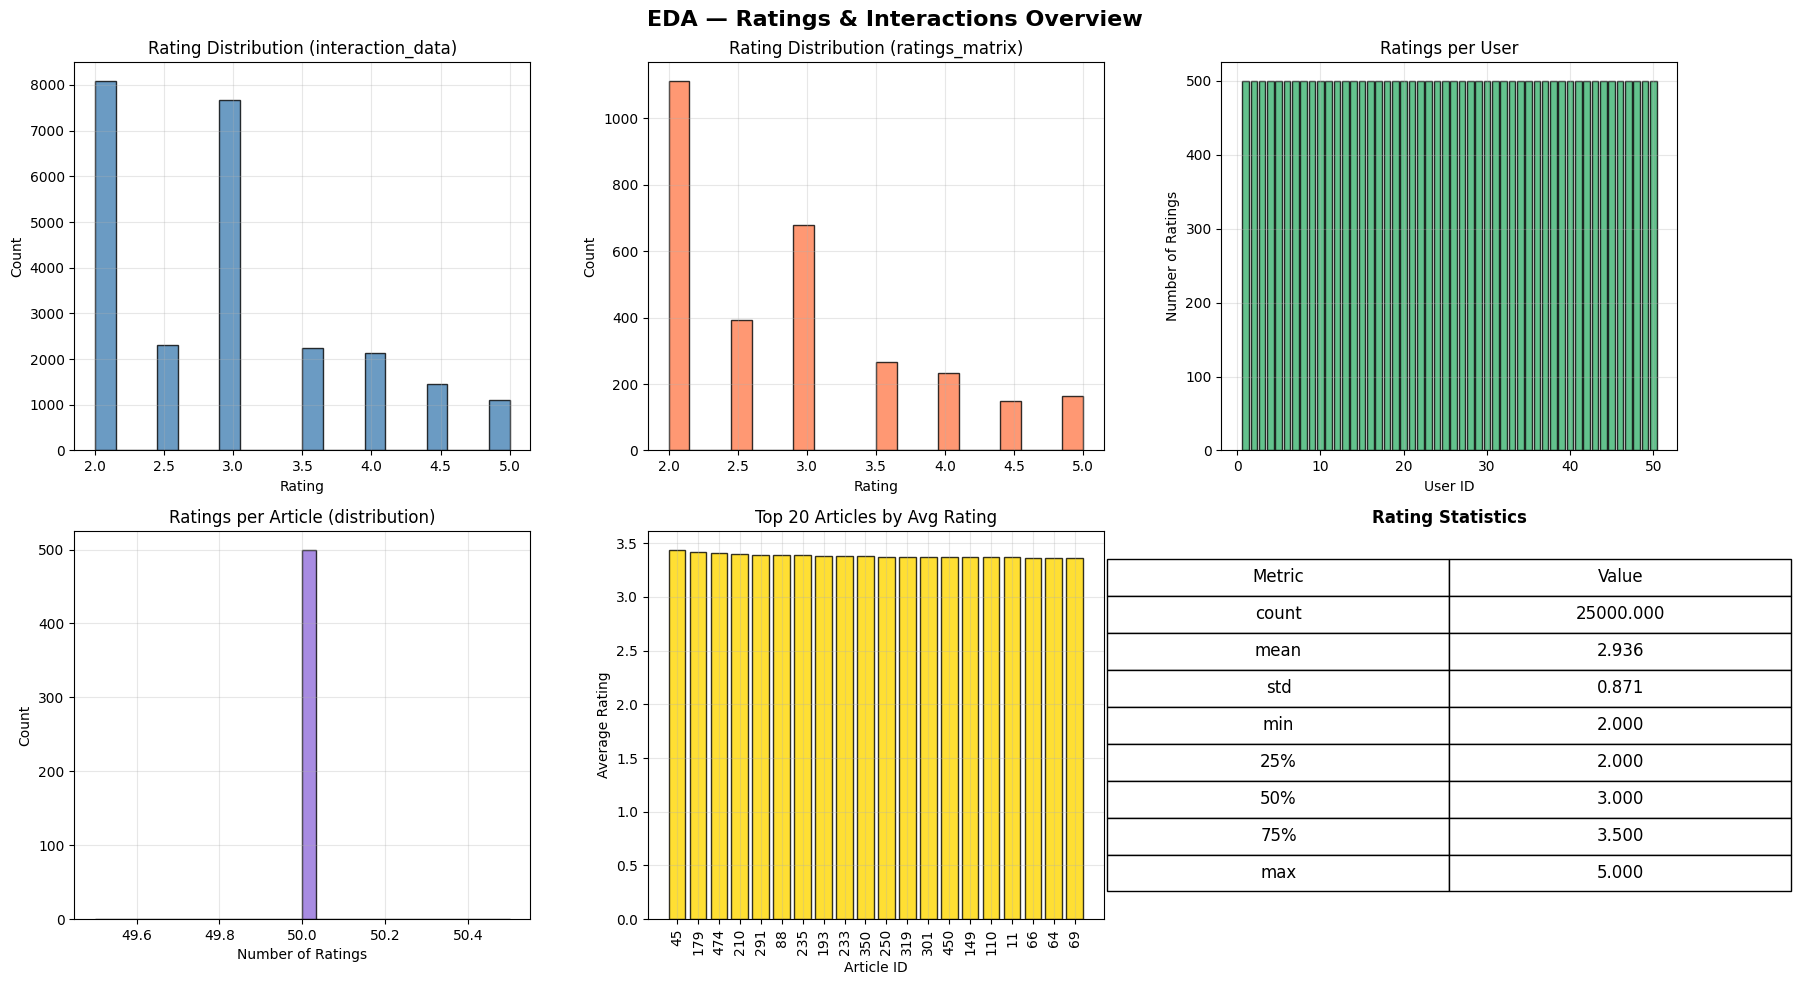


Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0
Sparsity        : 0.0000


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=16, fontweight='bold')

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=20,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rating Distribution (interaction_data)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=20,
               color='coral', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Rating Distribution (ratings_matrix)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Ratings per user
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].bar(ratings_per_user.index, ratings_per_user.values,
              color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,2].set_title('Ratings per User')
axes[0,2].set_xlabel('User ID')
axes[0,2].set_ylabel('Number of Ratings')
axes[0,2].grid(True, alpha=0.3)

# 4. Ratings per article
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Ratings per Article (distribution)')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(True, alpha=0.3)

# 5. Average rating per article (top 20)
avg_per_article = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(avg_per_article.index.astype(str), avg_per_article.values,
              color='gold', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Top 20 Articles by Avg Rating')
axes[1,1].set_xlabel('Article ID')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 6. Rating stats summary
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k, f"{v:.3f}"] for k, v in stats.items()]
table = axes[1,2].table(cellText=table_data,
                         colLabels=['Metric', 'Value'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique users    : {interaction_data['user_id'].nunique()}")
print(f"Unique articles : {interaction_data['article_id'].nunique()}")
print(f"Total ratings   : {len(interaction_data)}")
print(f"Rating range    : {interaction_data['rating'].min()} → {interaction_data['rating'].max()}")
print(f"Sparsity        : {1 - len(ratings_matrix)/(ratings_matrix['user_id'].nunique()*ratings_matrix['article_id'].nunique()):.4f}")

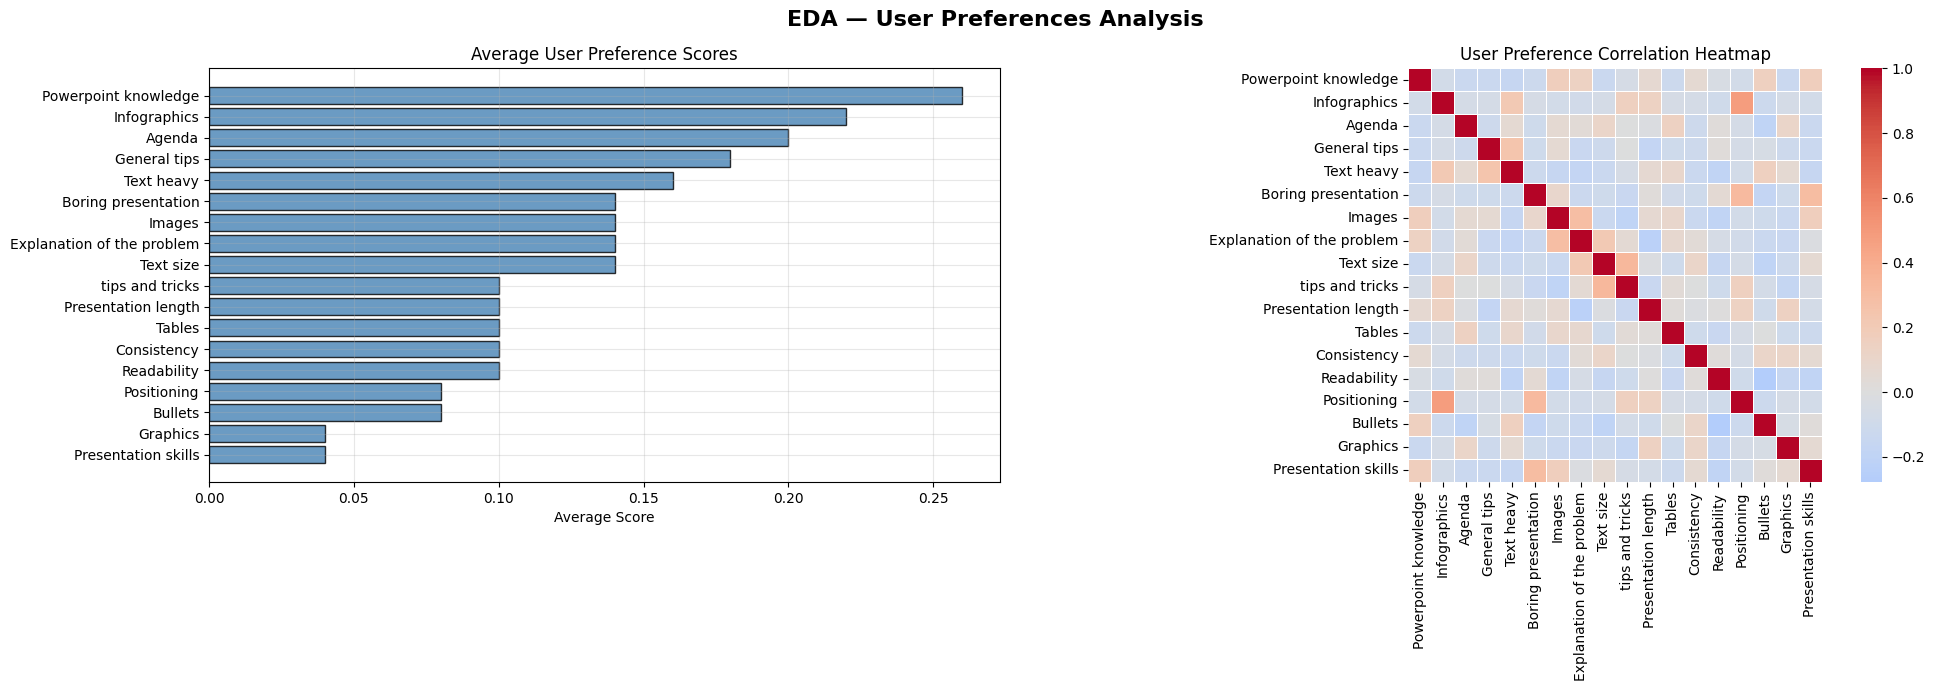

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# User preference columns
pref_cols = [c for c in interaction_data.columns if c.startswith('user_preference_')]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('EDA — User Preferences Analysis', fontsize=16, fontweight='bold')

# ---- 1. Average preference scores ----
avg_prefs = interaction_data[pref_cols].mean().sort_values(ascending=False)
clean_labels = [c.replace('user_preference_', '') for c in avg_prefs.index]

axes[0].barh(clean_labels, avg_prefs.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Average User Preference Scores')
axes[0].set_xlabel('Average Score')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# ---- 2. FULL Correlation heatmap (no masking) ----
pref_corr = interaction_data[pref_cols].corr()

sns.heatmap(pref_corr,
            ax=axes[1],
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            xticklabels=clean_labels,
            yticklabels=clean_labels,
            annot=False)

axes[1].set_title('User Preference Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [10]:
# Check if you already have a merged dataframe
# Based on your EDA output, your merged df has 83 columns
# Let's recreate it properly

df_merged = interaction_data.copy()

# Merge user_profiles
df_merged = df_merged.merge(
    user_profiles[['user_id', 'type', 'location',
                   'preferences', 'preferred_presentation_type']],
    on='user_id',
    how='left',
    suffixes=('', '_user')
)

# Merge recommendations (article-level info)
df_merged = df_merged.merge(
    recommendations[['article_id', 'presentation_type',
                      'audience_type', 'Main issue', 'popularity']],
    on='article_id',
    how='left',
    suffixes=('', '_rec')
)

print(f"Merged shape: {df_merged.shape}")
print(f"\nConfirm columns exist:")
print(f"  preferred_presentation_type : {'preferred_presentation_type' in df_merged.columns}")
print(f"  audience_type               : {'audience_type' in df_merged.columns}")
print(f"  presentation_type           : {'presentation_type' in df_merged.columns}")

Merged shape: (25000, 83)

Confirm columns exist:
  preferred_presentation_type : True
  audience_type               : True
  presentation_type           : True


=== CHECKING DATAFRAMES ===

interaction_data shape  : (25000, 75)
user_profiles shape     : (30, 5)
recommendations shape   : (100, 26)

df_merged shape         : (25000, 83)
df_merged columns       : ['user_id', 'article_id', 'rating', 'timestamp', 'location', 'user_preference_Boring presentation', 'user_preference_Graphics', 'user_preference_Readability', 'user_preference_Consistency', 'user_preference_Images', 'user_preference_Bullets', 'user_preference_Text size', 'user_preference_Text heavy', 'user_preference_Tables', 'user_preference_Agenda', 'user_preference_Infographics', 'user_preference_Positioning', 'user_preference_Presentation length', 'user_preference_General tips', 'user_preference_Presentation skills', 'user_preference_Powerpoint knowledge', 'user_preference_tips and tricks', 'user_preference_Explanation of the problem', 'user_type_business', 'user_type_teacher', 'user_type_student', 'user_type_researcher', 'user_type_manager', 'user_type_technical', 'user_type_special

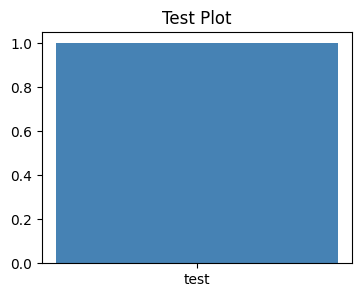


If you see a bar chart above, matplotlib is working fine


In [12]:
# ── DIAGNOSTIC: Run this and paste the output ─────────────

print("=== CHECKING DATAFRAMES ===")
print(f"\ninteraction_data shape  : {interaction_data.shape}")
print(f"user_profiles shape     : {user_profiles.shape}")
print(f"recommendations shape   : {recommendations.shape}")

# Check if df_merged exists
try:
    print(f"\ndf_merged shape         : {df_merged.shape}")
    print(f"df_merged columns       : {df_merged.columns.tolist()}")
except NameError:
    print("\ndf_merged does NOT exist — you skipped the Fix cell")

# Check what columns interaction_data actually has
print("\n=== INTERACTION_DATA COLUMNS ===")
for col in interaction_data.columns.tolist():
    print(f"  {col}")

# Check user_profiles columns
print("\n=== USER_PROFILES COLUMNS ===")
for col in user_profiles.columns.tolist():
    print(f"  {col}")

# Check recommendations columns
print("\n=== RECOMMENDATIONS COLUMNS ===")
for col in recommendations.columns.tolist():
    print(f"  {col}")

# Check if matplotlib is working at all
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.bar(['test'], [1], color='steelblue')
ax.set_title('Test Plot')
plt.show()
print("\nIf you see a bar chart above, matplotlib is working fine")

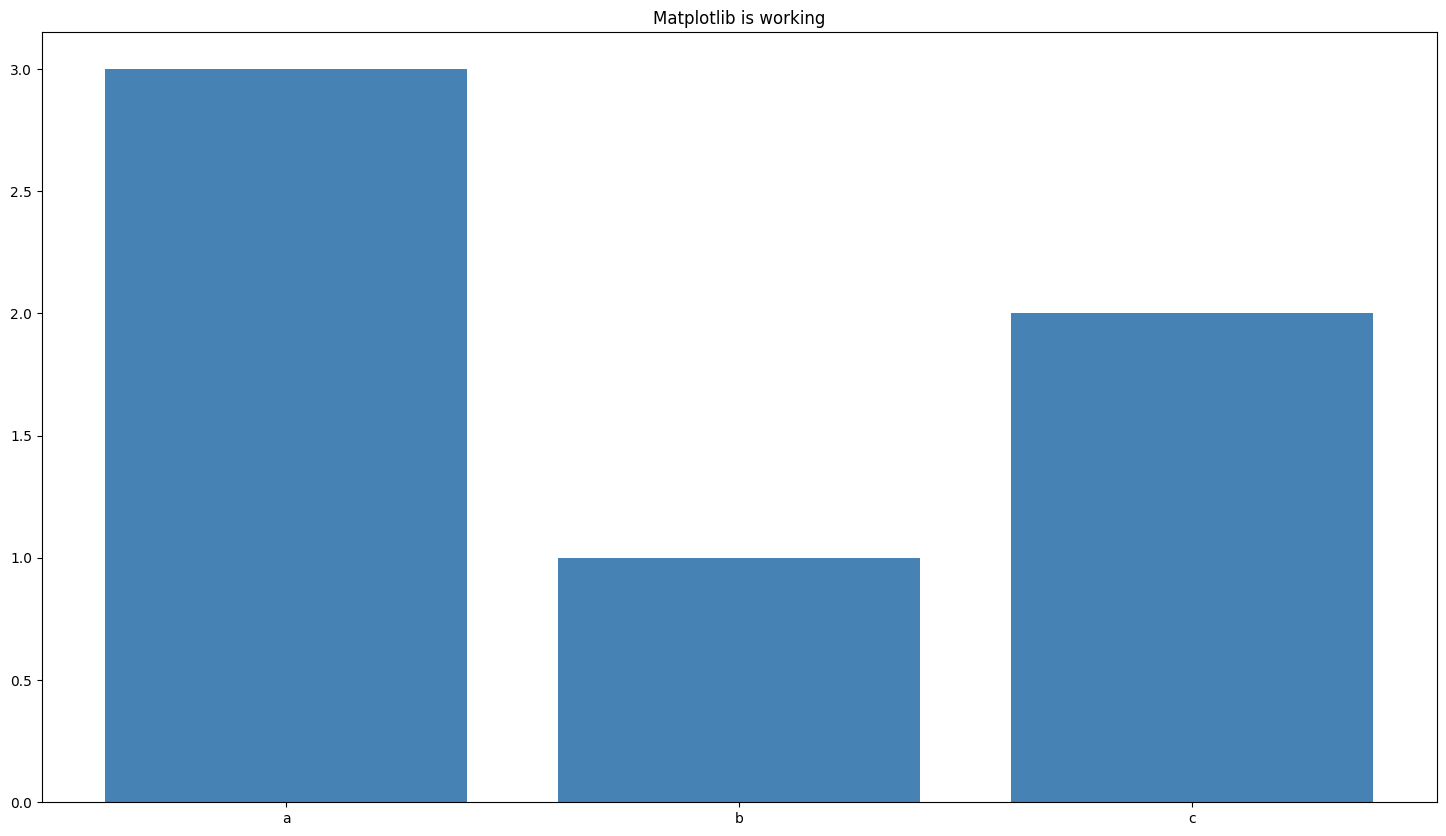

If you see the bar chart, you are good to go


In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (18, 10)
matplotlib.rcParams['figure.dpi']     = 100

# Quick test
fig, ax = plt.subplots()
ax.bar(['a','b','c'], [3,1,2], color='steelblue')
ax.set_title('Matplotlib is working')
plt.show()
print("If you see the bar chart, you are good to go")

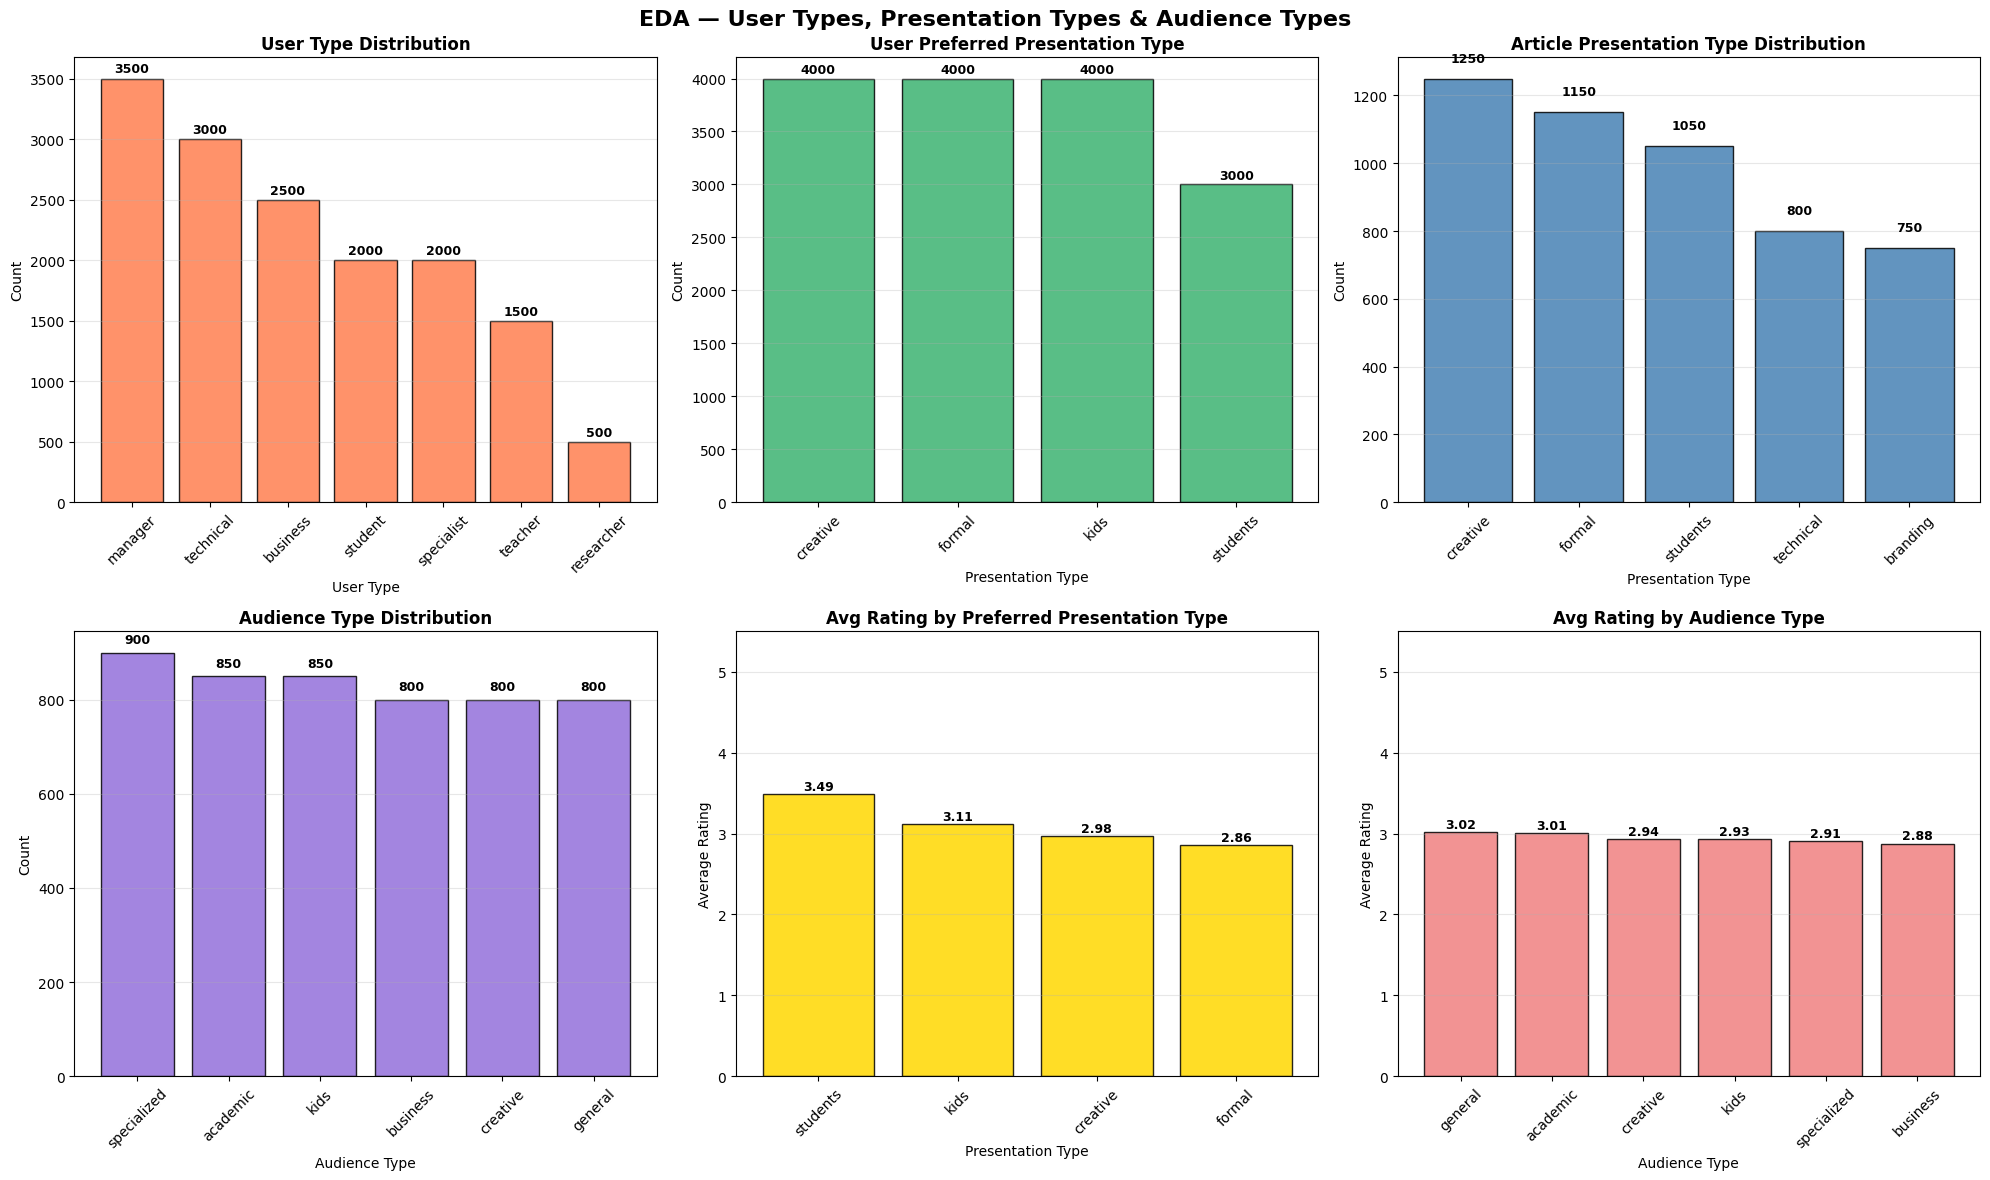


User Type Counts:
type
manager       3500
technical     3000
business      2500
student       2000
specialist    2000
teacher       1500
researcher     500

Preferred Presentation Type Counts:
preferred_presentation_type
creative    4000
formal      4000
kids        4000
students    3000

Article Presentation Type Counts:
presentation_type
creative     1250
formal       1150
students     1050
technical     800
branding      750

Audience Type Counts:
audience_type
specialized    900
academic       850
kids           850
business       800
creative       800
general        800


In [15]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('EDA — User Types, Presentation Types & Audience Types',
             fontsize=16, fontweight='bold')

# ── Plot 1: User Types (from string column in df_merged) ─
user_type_counts = df_merged['type'].value_counts()

bars1 = axes[0,0].bar(user_type_counts.index, user_type_counts.values,
                       color='coral', edgecolor='black', alpha=0.85)
axes[0,0].set_title('User Type Distribution', fontweight='bold')
axes[0,0].set_xlabel('User Type')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, user_type_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: User Preferred Presentation Type ─────────────
pref_ptype = df_merged['preferred_presentation_type'].value_counts()

bars2 = axes[0,1].bar(pref_ptype.index, pref_ptype.values,
                       color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[0,1].set_title('User Preferred Presentation Type', fontweight='bold')
axes[0,1].set_xlabel('Presentation Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, pref_ptype.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 3: Article Presentation Type ────────────────────
# Use the string column from recommendations merge
art_ptype = df_merged['presentation_type'].value_counts()

bars3 = axes[0,2].bar(art_ptype.index, art_ptype.values,
                       color='steelblue', edgecolor='black', alpha=0.85)
axes[0,2].set_title('Article Presentation Type Distribution', fontweight='bold')
axes[0,2].set_xlabel('Presentation Type')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, art_ptype.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 4: Audience Type Distribution ───────────────────
# Use string column, NOT one-hot columns (those are all zeros)
aud_counts = df_merged['audience_type'].value_counts()

bars4 = axes[1,0].bar(aud_counts.index, aud_counts.values,
                       color='mediumpurple', edgecolor='black', alpha=0.85)
axes[1,0].set_title('Audience Type Distribution', fontweight='bold')
axes[1,0].set_xlabel('Audience Type')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, aud_counts.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 20,
                   str(val), ha='center', fontsize=9, fontweight='bold')

# ── Plot 5: Avg Rating by Preferred Presentation Type ────
avg_by_ptype = (df_merged
                .groupby('preferred_presentation_type')['rating']
                .mean()
                .sort_values(ascending=False))

bars5 = axes[1,1].bar(avg_by_ptype.index, avg_by_ptype.values,
                       color='gold', edgecolor='black', alpha=0.85)
axes[1,1].set_title('Avg Rating by Preferred Presentation Type',
                     fontweight='bold')
axes[1,1].set_xlabel('Presentation Type')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].set_ylim(0, 5.5)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars5, avg_by_ptype.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 6: Avg Rating by Audience Type ──────────────────
avg_by_aud = (df_merged
              .groupby('audience_type')['rating']
              .mean()
              .sort_values(ascending=False))

bars6 = axes[1,2].bar(avg_by_aud.index, avg_by_aud.values,
                       color='lightcoral', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Avg Rating by Audience Type', fontweight='bold')
axes[1,2].set_xlabel('Audience Type')
axes[1,2].set_ylabel('Average Rating')
axes[1,2].set_ylim(0, 5.5)
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars6, avg_by_aud.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_user_presentation_types.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print the actual values ───────────────────────────────
print("\nUser Type Counts:")
print(user_type_counts.to_string())
print("\nPreferred Presentation Type Counts:")
print(pref_ptype.to_string())
print("\nArticle Presentation Type Counts:")
print(art_ptype.to_string())
print("\nAudience Type Counts:")
print(aud_counts.to_string())

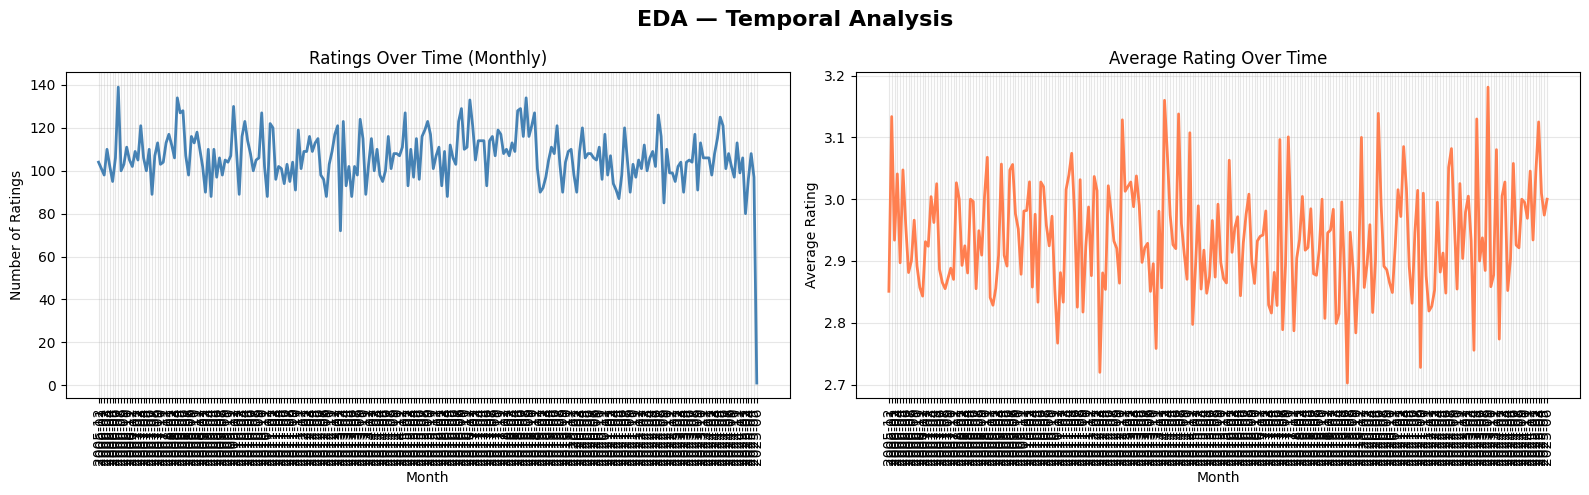

In [17]:
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('EDA — Temporal Analysis', fontsize=16, fontweight='bold')

# Ratings over time
interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_counts = interaction_data.groupby('year_month').size()
axes[0].plot(monthly_counts.index.astype(str), monthly_counts.values,
             color='steelblue', linewidth=2)
axes[0].set_title('Ratings Over Time (Monthly)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Ratings')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(True, alpha=0.3)

# Average rating over time
monthly_avg = interaction_data.groupby('year_month')['rating'].mean()
axes[1].plot(monthly_avg.index.astype(str), monthly_avg.values,
             color='coral', linewidth=2)
axes[1].set_title('Average Rating Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Rating')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
print("Starting Feature Engineering...")

df = interaction_data.copy()

# ── 1. Timestamp features ─────────────────────────────────
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month

# Cyclic encoding (matches paper's sinusoidal approach)
df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)
df['day_sin']   = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['dayofweek'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month']     / 12)

# Days since first interaction per user
df = df.sort_values('timestamp')
first_ts = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days

# ── 2. User activity features ─────────────────────────────
user_stats = df.groupby('user_id').agg(
    user_avg_rating    = ('rating', 'mean'),
    user_rating_count  = ('rating', 'count'),
    user_rating_std    = ('rating', 'std')
).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')

# ── 3. Item activity features ─────────────────────────────
item_stats = df.groupby('article_id').agg(
    item_avg_rating   = ('rating', 'mean'),
    item_rating_count = ('rating', 'count'),
    item_rating_std   = ('rating', 'std')
).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')

# ── 4. User-item match score ──────────────────────────────
pref_cols  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols = ['Boring presentation','Graphics','Readability','Consistency',
              'Images','Bullets','Text size','Text heavy','Tables',
              'Agenda','Infographics','Positioning']

# How many issues match user preferences
def compute_match(row):
    score = 0
    for p, i in zip(pref_cols, issue_cols):
        if i in row.index:
            score += int(row[p] == row[i])
    return score

tqdm.pandas(desc="Computing match scores")
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)

# ── 5. Exponential decay weight (paper's approach) ────────
decay_rate = 0.01
df['time_decay_weight'] = np.exp(-decay_rate * df['days_since_first'])

# ── 6. Normalize continuous features ─────────────────────
scaler = MinMaxScaler()
cols_to_scale = ['days_since_first','user_avg_rating','user_rating_count',
                 'user_rating_std','item_avg_rating','item_rating_count',
                 'item_rating_std','preference_match_score','time_decay_weight']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Feature engineering done. Final shape: {df.shape}")
print(f"New columns added: {df.shape[1] - interaction_data.shape[1]}")
df.head(3)

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:01<00:00, 21289.34it/s]


Feature engineering done. Final shape: (25000, 94)
New columns added: 18


,user_id,article_id,rating,timestamp,location,user_preference_Boring presentation,user_preference_Graphics,user_preference_Readability,user_preference_Consistency,user_preference_Images,...,month_cos,days_since_first,user_avg_rating,user_rating_count,user_rating_std,item_avg_rating,item_rating_count,item_rating_std,preference_match_score,time_decay_weight
0,13,114,3.0,2005-12-01 07:00:00,Florida,0,0,0,0,0,...,1.0,0.0,0.437714,0.0,0.902715,0.000000,0.0,0.086354,0.500000,1.0
1,14,474,2.5,2005-12-01 12:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.232717,0.0,0.838889,0.960000,0.0,0.957237,0.416667,1.0
2,17,449,4.5,2005-12-01 17:00:00,Illinois,0,0,0,0,0,...,1.0,0.0,0.107118,0.0,0.980352,0.866667,0.0,0.532169,0.333333,1.0


In [19]:
# Use ratings_matrix for the CF autoencoder
# It's the clean ratings table: user_id, article_id, rating

rm = ratings_matrix.copy()

user_ids_rm = rm['user_id'].unique()
item_ids_rm = rm['article_id'].unique()

user2idx = {uid: i for i, uid in enumerate(sorted(user_ids_rm))}
item2idx = {iid: i for i, iid in enumerate(sorted(item_ids_rm))}

rm['user_idx'] = rm['user_id'].map(user2idx)
rm['item_idx'] = rm['article_id'].map(item2idx)

n_users = len(user_ids_rm)
n_items = len(item_ids_rm)

rating_min = rm['rating'].min()
rating_max = rm['rating'].max()

def normalize(r):
    return (r - rating_min) / (rating_max - rating_min)

def denormalize(r):
    return r * (rating_max - rating_min) + rating_min

# Build matrix
user_item_matrix = np.zeros((n_users, n_items), dtype=np.float32)
for _, row in tqdm(rm.iterrows(), total=len(rm), desc="Building matrix"):
    user_item_matrix[int(row['user_idx']), int(row['item_idx'])] = normalize(row['rating'])

print(f"Matrix shape   : {user_item_matrix.shape}")
print(f"Non-zero cells : {np.count_nonzero(user_item_matrix)}")
print(f"Sparsity       : {1 - np.count_nonzero(user_item_matrix)/(n_users*n_items):.4f}")
print(f"Rating range   : {rating_min} → {rating_max}")

Building matrix: 100%|██████████| 3000/3000 [00:00<00:00, 25805.28it/s]

Matrix shape   : (30, 100)
Non-zero cells : 1887
Sparsity       : 0.3710
Rating range   : 2.0 → 5.0


In [20]:
all_users = np.arange(n_users)

train_u, temp_u = train_test_split(all_users, test_size=0.30, random_state=42)
val_u,   test_u = train_test_split(temp_u,    test_size=0.50, random_state=42)

X_train = user_item_matrix[train_u]
X_val   = user_item_matrix[val_u]
X_test  = user_item_matrix[test_u]

# Keep interaction rows for evaluation
rm_train = rm[rm['user_idx'].isin(train_u)].copy()
rm_val   = rm[rm['user_idx'].isin(val_u)].copy()
rm_test  = rm[rm['user_idx'].isin(test_u)].copy()

# Local index map for test users
test_local = {uid: i for i, uid in enumerate(test_u)}

print(f"Train : {X_train.shape}  ({len(rm_train)} interactions)")
print(f"Val   : {X_val.shape}  ({len(rm_val)} interactions)")
print(f"Test  : {X_test.shape}  ({len(rm_test)} interactions)")

Train : (21, 100)  (2100 interactions)
Val   : (4, 100)  (400 interactions)
Test  : (5, 100)  (500 interactions)


In [21]:
# KEY IMPROVEMENTS over the paper's basic autoencoder:
# 1. Masked loss  — only penalise rated items, not zeros
# 2. Denoising    — randomly zero out inputs during training
# 3. Batch norm   — faster convergence, better generalisation
# 4. Deeper arch  — richer latent space

def masked_mse(y_true, y_pred):
    """Only compute loss on non-zero (actually rated) entries."""
    mask  = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    diff  = tf.square((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)

def masked_mae(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    diff = tf.abs((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)

def build_autoencoder(input_dim,
                      enc_units   = [512, 256, 128],
                      latent_dim  = 64,
                      dropout_rate= 0.3,
                      l2_reg      = 1e-5,
                      learning_rate=1e-3):

    reg = tf.keras.regularizers.l2(l2_reg)

    inp = Input(shape=(input_dim,), name='user_vector')

    # Denoising: randomly drop inputs during training
    x = layers.Dropout(0.2)(inp)  # input noise

    # Encoder
    for units in enc_units:
        x = layers.Dense(units, activation='relu',
                          kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    encoded = layers.Dense(latent_dim, activation='relu',
                            name='latent')(x)

    # Decoder (mirror)
    x = encoded
    for units in reversed(enc_units):
        x = layers.Dense(units, activation='relu',
                          kernel_regularizer=reg)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    output = layers.Dense(input_dim, activation='sigmoid',
                           name='reconstruction')(x)

    model = Model(inp, output, name='ImprovedCF_Autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=masked_mse,
        metrics=[masked_mae]
    )
    return model

# Preview
model_preview = build_autoencoder(input_dim=n_items)
model_preview.summary()

I0000 00:00:1774070187.316226      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774070187.322161      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "ImprovedCF_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ user_vector (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 100)            │        51,30

 Total params: 455,588 (1.74 MB)

 Trainable params: 452,004 (1.72 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [28]:
def masked_mse(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    diff = tf.square((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)

def masked_mae(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0.0), tf.float32)
    diff = tf.abs((y_true - y_pred) * mask)
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) + 1e-8)

def build_autoencoder(input_dim,
                      enc_units    = [256, 128],
                      latent_dim   = 32,
                      dropout_rate = 0.3,
                      l2_reg       = 1e-5,
                      lr           = 1e-3):       # ← lr not learning_rate
    reg = tf.keras.regularizers.l2(l2_reg)
    inp = Input(shape=(input_dim,), name='user_rating_vector')
    x   = layers.Dropout(0.2, name='input_noise')(inp)

    for i, units in enumerate(enc_units):
        x = layers.Dense(units, activation='relu',
                          kernel_regularizer=reg,
                          name=f'encoder_{i}')(x)
        x = layers.BatchNormalization(name=f'bn_enc_{i}')(x)
        x = layers.Dropout(dropout_rate, name=f'drop_enc_{i}')(x)

    encoded = layers.Dense(latent_dim, activation='relu',
                            name='latent')(x)
    x = encoded

    for i, units in enumerate(reversed(enc_units)):
        x = layers.Dense(units, activation='relu',
                          kernel_regularizer=reg,
                          name=f'decoder_{i}')(x)
        x = layers.BatchNormalization(name=f'bn_dec_{i}')(x)
        x = layers.Dropout(dropout_rate, name=f'drop_dec_{i}')(x)

    output = layers.Dense(input_dim, activation='sigmoid',
                           name='reconstruction')(x)

    model = Model(inp, output, name='CF_Autoencoder')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),   # ← lr here
        loss=masked_mse,
        metrics=[masked_mae]
    )
    return model

# Quick test to confirm it works
test_m = build_autoencoder(input_dim=10, enc_units=[32], latent_dim=8, lr=1e-3)
print("build_autoencoder redefined successfully with lr parameter")
print("Now rerun Cell 13")

build_autoencoder redefined successfully with lr parameter
Now rerun Cell 13


STEP 1: HYPERPARAMETER TUNING

Config 1/5: {'enc_units': [256, 128], 'latent_dim': 32, 'dropout': 0.3, 'lr': 0.001}
Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 794ms/step - loss: 0.1346 - masked_mae: 0.2977 - val_loss: 0.0426 - val_masked_mae: 0.1512
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1281 - masked_mae: 0.2879 - val_loss: 0.0424 - val_masked_mae: 0.1514
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1138 - masked_mae: 0.2660 - val_loss: 0.0422 - val_masked_mae: 0.1517
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1160 - masked_mae: 0.2698 - val_loss: 0.0423 - val_masked_mae: 0.1526
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1186 - masked_mae: 0.2781 - val_loss: 0.0423 - val_masked_mae: 0.1534
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1070 - masked_mae: 0.2604 - val_loss: 0.0421 - val_masked_mae: 0.1536
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1112 - masked_mae: 0.2635 - val_loss: 0.0420 - va

Extracting predictions: 100%|██████████| 500/500 [00:00<00:00, 19126.92it/s]


  MAE  : 0.7861   (paper: 3.05)
  MSE  : 0.7964  (paper: 10.46)
  RMSE : 0.8924   (paper: 3.23)

  Beats paper? YES

STEP 5: SAVING
  saved_models/autoencoder_final.keras
  saved_models/autoencoder_metrics.json


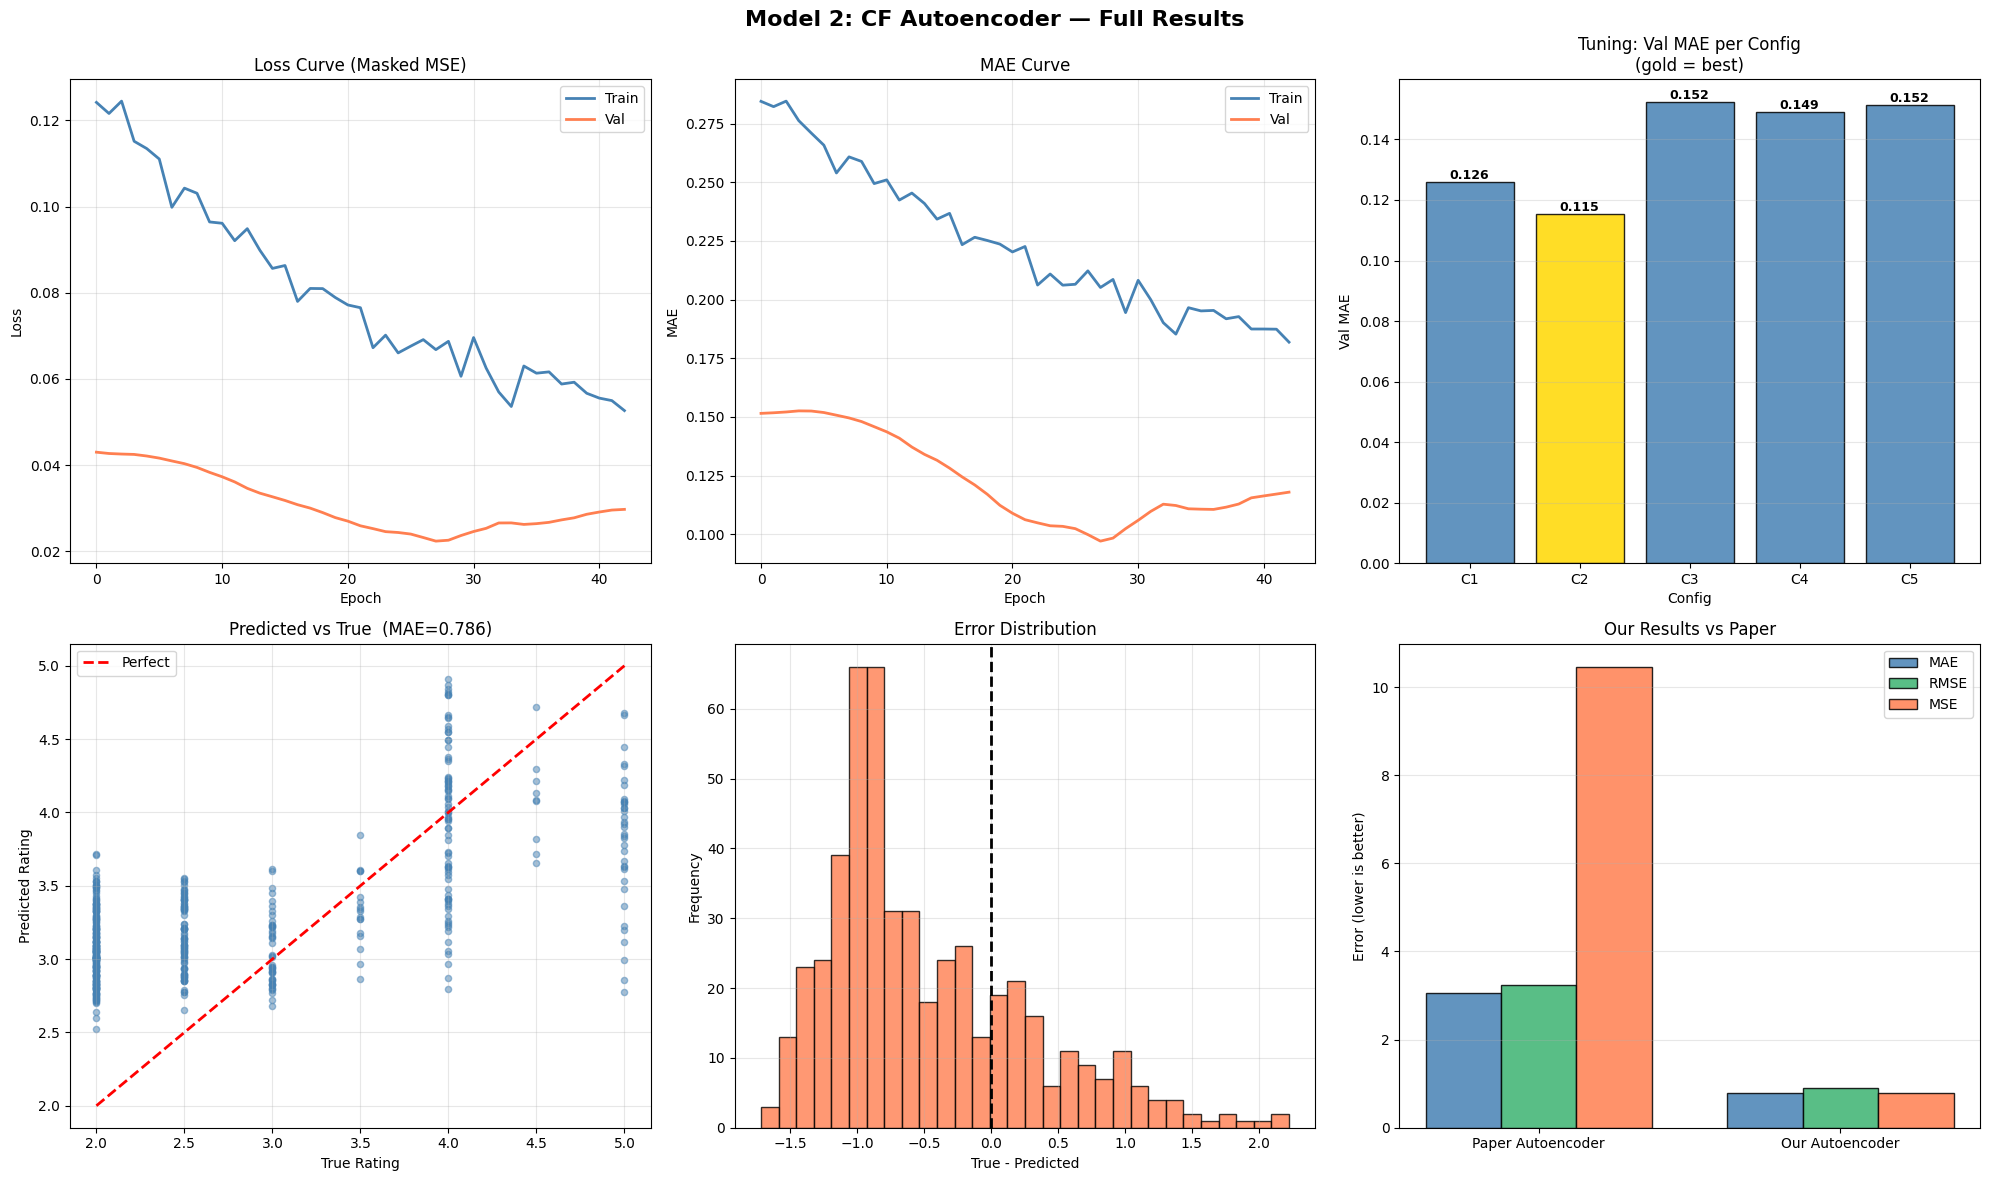


  FINAL SUMMARY — MODEL 2: CF AUTOENCODER
  Best config      : {'enc_units': [256, 128], 'latent_dim': 64, 'dropout': 0.2, 'lr': 0.001}
  Epochs ran       : 43
  Training time    : 0:00:17
  Best train loss  : 0.0527
  Best val loss    : 0.0224
  Best train MAE   : 0.1819
  Best val MAE     : 0.0971
  Test MAE         : 0.7861   (paper: 3.05)
  Test MSE         : 0.7964  (paper: 10.46)
  Test RMSE        : 0.8924   (paper: 3.23)
  Beats paper?     : YES


In [29]:
# ── STEP 1: HYPERPARAMETER TUNING ────────────────────────
print("="*60)
print("STEP 1: HYPERPARAMETER TUNING")
print("="*60)

# Smaller configs — right-sized for your dataset
# (3000 rows, 500 items, 50 users)
configs = [
    {'enc_units':[256, 128],      'latent_dim':32,  'dropout':0.3, 'lr':1e-3},
    {'enc_units':[256, 128],      'latent_dim':64,  'dropout':0.2, 'lr':1e-3},
    {'enc_units':[128, 64],       'latent_dim':32,  'dropout':0.3, 'lr':5e-4},
    {'enc_units':[256, 128, 64],  'latent_dim':32,  'dropout':0.2, 'lr':1e-3},
    {'enc_units':[128, 64],       'latent_dim':16,  'dropout':0.4, 'lr':5e-4},
]

tuning_results = []

for i, cfg in enumerate(configs):
    print(f"\nConfig {i+1}/{len(configs)}: {cfg}")

    m = build_autoencoder(
        input_dim    = n_items,
        enc_units    = cfg['enc_units'],
        latent_dim   = cfg['latent_dim'],
        dropout_rate = cfg['dropout'],
        lr           = cfg['lr']
    )

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    h = m.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=20,        # reduced from 30
        batch_size=4,     # smaller batch for tiny dataset
        callbacks=[es],
        verbose=1         # show progress so you know it's running
    )

    bvl   = min(h.history['val_loss'])
    bvmae = min(h.history['val_masked_mae'])
    btl   = min(h.history['loss'])
    btmae = min(h.history['masked_mae'])
    ep    = len(h.history['loss'])

    print(f"  Epochs       : {ep}")
    print(f"  Train loss   : {btl:.4f}  |  Val loss : {bvl:.4f}")
    print(f"  Train MAE    : {btmae:.4f}  |  Val MAE  : {bvmae:.4f}")

    tuning_results.append({
        'config'    : cfg,
        'val_loss'  : bvl,
        'val_mae'   : bvmae,
        'train_loss': btl,
        'train_mae' : btmae,
        'epochs'    : ep
    })

print("\n" + "="*60)
print("TUNING SUMMARY")
print("="*60)
print(f"{'Cfg':<5}{'Train Loss':>12}{'Val Loss':>10}"
      f"{'Train MAE':>11}{'Val MAE':>9}{'Epochs':>7}")
print("-"*55)
for i, r in enumerate(tuning_results):
    print(f"  {i+1:<4}{r['train_loss']:>12.4f}{r['val_loss']:>10.4f}"
          f"{r['train_mae']:>11.4f}{r['val_mae']:>9.4f}{r['epochs']:>7}")

best     = min(tuning_results, key=lambda x: x['val_mae'])
best_cfg = best['config']
print(f"\nBest config  : {best_cfg}")
print(f"Best val MAE : {best['val_mae']:.4f}")


# ── STEP 2: TRAIN FINAL MODEL ─────────────────────────────
print("\n" + "="*60)
print("STEP 2: TRAINING FINAL MODEL")
print("="*60)

final_model = build_autoencoder(
    input_dim    = n_items,
    enc_units    = best_cfg['enc_units'],
    latent_dim   = best_cfg['latent_dim'],
    dropout_rate = best_cfg['dropout'],
    lr           = best_cfg['lr']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_models/best_autoencoder.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

start   = time.time()
history = final_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=4,
    callbacks=callbacks,
    verbose=1             # show every epoch
)
training_time = time.time() - start


# ── STEP 3: TRAINING METRICS ──────────────────────────────
print("\n" + "="*60)
print("STEP 3: TRAINING METRICS SUMMARY")
print("="*60)

best_train_loss = min(history.history['loss'])
best_val_loss   = min(history.history['val_loss'])
best_train_mae  = min(history.history['masked_mae'])
best_val_mae_f  = min(history.history['val_masked_mae'])
total_epochs    = len(history.history['loss'])

print(f"  Epochs ran       : {total_epochs}")
print(f"  Training time    : {str(timedelta(seconds=int(training_time)))}")
print(f"  Best train loss  : {best_train_loss:.4f}")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best train MAE   : {best_train_mae:.4f}")
print(f"  Best val MAE     : {best_val_mae_f:.4f}")


# ── STEP 4: TEST SET EVALUATION ───────────────────────────
print("\n" + "="*60)
print("STEP 4: TEST SET EVALUATION")
print("="*60)

reconstructed        = final_model.predict(X_test, verbose=1)
y_true_ae, y_pred_ae = [], []

for _, row in tqdm(rm_test.iterrows(), total=len(rm_test),
                   desc="Extracting predictions"):
    uid       = int(row['user_idx'])
    iid       = int(row['item_idx'])
    local_idx = test_local.get(uid)
    if local_idx is None:
        continue
    pred = denormalize(float(reconstructed[local_idx, iid]))
    pred = np.clip(pred, rating_min, rating_max)
    y_true_ae.append(float(row['rating']))
    y_pred_ae.append(pred)

y_true_ae = np.array(y_true_ae)
y_pred_ae = np.array(y_pred_ae)

mae_ae  = mean_absolute_error(y_true_ae, y_pred_ae)
mse_ae  = mean_squared_error(y_true_ae, y_pred_ae)
rmse_ae = np.sqrt(mse_ae)

print(f"\n  MAE  : {mae_ae:.4f}   (paper: 3.05)")
print(f"  MSE  : {mse_ae:.4f}  (paper: 10.46)")
print(f"  RMSE : {rmse_ae:.4f}   (paper: 3.23)")
print(f"\n  Beats paper? {'YES' if mae_ae < 3.05 else 'NO'}")


# ── STEP 5: SAVE ──────────────────────────────────────────
print("\n" + "="*60)
print("STEP 5: SAVING")
print("="*60)

final_model.save('saved_models/autoencoder_final.keras')

ae_metrics = {
    'model'          : 'CF Autoencoder',
    'best_config'    : str(best_cfg),
    'total_epochs'   : total_epochs,
    'training_time'  : str(timedelta(seconds=int(training_time))),
    'best_train_loss': round(best_train_loss, 4),
    'best_val_loss'  : round(best_val_loss,   4),
    'best_train_mae' : round(best_train_mae,  4),
    'best_val_mae'   : round(best_val_mae_f,  4),
    'test_MAE'       : round(float(mae_ae),   4),
    'test_MSE'       : round(float(mse_ae),   4),
    'test_RMSE'      : round(float(rmse_ae),  4),
    'paper_MAE'      : 3.05,
    'beats_paper'    : bool(mae_ae < 3.05)
}
with open('saved_models/autoencoder_metrics.json', 'w') as f:
    json.dump(ae_metrics, f, indent=2)

print("  saved_models/autoencoder_final.keras")
print("  saved_models/autoencoder_metrics.json")


# ── STEP 6: PLOTS ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model 2: CF Autoencoder — Full Results',
             fontsize=16, fontweight='bold')

axes[0,0].plot(history.history['loss'],
               label='Train', linewidth=2, color='steelblue')
axes[0,0].plot(history.history['val_loss'],
               label='Val',   linewidth=2, color='coral')
axes[0,0].set_title('Loss Curve (Masked MSE)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(history.history['masked_mae'],
               label='Train', linewidth=2, color='steelblue')
axes[0,1].plot(history.history['val_masked_mae'],
               label='Val',   linewidth=2, color='coral')
axes[0,1].set_title('MAE Curve')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

config_labels = [f"C{i+1}" for i in range(len(tuning_results))]
val_maes      = [r['val_mae'] for r in tuning_results]
best_idx      = val_maes.index(min(val_maes))
bar_colors    = ['gold' if i == best_idx else 'steelblue'
                 for i in range(len(config_labels))]
bars = axes[0,2].bar(config_labels, val_maes,
                      color=bar_colors, edgecolor='black', alpha=0.85)
axes[0,2].set_title('Tuning: Val MAE per Config\n(gold = best)')
axes[0,2].set_xlabel('Config')
axes[0,2].set_ylabel('Val MAE')
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, val_maes):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1,0].scatter(y_true_ae, y_pred_ae,
                  alpha=0.5, s=20, color='steelblue')
axes[1,0].plot([rating_min, rating_max],
               [rating_min, rating_max],
               'r--', linewidth=2, label='Perfect')
axes[1,0].set_title(f'Predicted vs True  (MAE={mae_ae:.3f})')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

errors = y_true_ae - y_pred_ae
axes[1,1].hist(errors, bins=30,
               color='coral', edgecolor='black', alpha=0.8)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution')
axes[1,1].set_xlabel('True - Predicted')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

x_pos    = np.arange(2)
w        = 0.25
mae_cmp  = [3.05,  mae_ae]
mse_cmp  = [10.46, mse_ae]
rmse_cmp = [3.23,  rmse_ae]
axes[1,2].bar(x_pos - w, mae_cmp,  width=w, label='MAE',
              color='steelblue',      edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos,     rmse_cmp, width=w, label='RMSE',
              color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos + w, mse_cmp,  width=w, label='MSE',
              color='coral',          edgecolor='black', alpha=0.85)
axes[1,2].set_title('Our Results vs Paper')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Paper Autoencoder','Our Autoencoder'])
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saved_models/autoencoder_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  FINAL SUMMARY — MODEL 2: CF AUTOENCODER")
print("="*65)
print(f"  Best config      : {best_cfg}")
print(f"  Epochs ran       : {total_epochs}")
print(f"  Training time    : {str(timedelta(seconds=int(training_time)))}")
print(f"  Best train loss  : {best_train_loss:.4f}")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best train MAE   : {best_train_mae:.4f}")
print(f"  Best val MAE     : {best_val_mae_f:.4f}")
print(f"  Test MAE         : {mae_ae:.4f}   (paper: 3.05)")
print(f"  Test MSE         : {mse_ae:.4f}  (paper: 10.46)")
print(f"  Test RMSE        : {rmse_ae:.4f}   (paper: 3.23)")
print(f"  Beats paper?     : {'YES' if mae_ae < 3.05 else 'NO'}")
print("="*65)